> **Historical / superseded.** This is the *pseudo-likelihood* three-body diagnostic. Its takeaway — PL matches conditionals not moments, so its model marginals over-concentrate and a Schneidman three-body test on it is uninterpretable — is what motivated the Boltzmann (moment-matching) fit. The live three-body test now lives in `boltzmann_learning.ipynb`, run on the moment-matched model. Kept here for the record only. (Note: this notebook's PT ladder starts the cold chain at T=0.5, which samples a sharper-than-model distribution; `boltzmann_learning.ipynb` fixes that to T=1.)

# Three-body calibration: how well does the pairwise PL fit reproduce third-order team structure?

**What this is — and what it is not.** Everything downstream of the inverse Ising fits assumes team structure is captured by *pairs*: the model family
$$P(s) \propto \exp\Big(h\cdot s + \tfrac{1}{2}\, s' J s\Big), \qquad \textstyle\sum_i s_i = 6$$
carries no explicit three-body terms. The textbook test (Schneidman et al., retinal populations) asks whether a pairwise model nonetheless *predicts* the data's connected three-point correlations; if it does, the pairwise assumption is earned. **That test presumes a moment-matched fit** — a MaxEnt / Boltzmann-learned model whose 1st- and 2nd-order moments equal the data's by construction. Our production models are fit by **pseudo-likelihood**, which matches *conditionals*, not *moments*: the PL fit's own 1- and 2-point moments already differ from the data's, so a 3-point gap here is dominated by that lower-order mismatch and cannot be read as "missing three-body physics."

This notebook is therefore a **generative-calibration diagnostic**, not a verdict on the pairwise assumption: it measures how far the PL fit's generated distribution drifts from the data across the 1st / 2nd / 3rd moments *together*, with the lower moments as the calibration baseline. A clean three-body test is deferred to the separate Boltzmann-learning track (see "Reading the result").

**Statistic.** The connected three-point correlation
$$T_{ijk} = \big\langle (s_i - m_i)(s_j - m_j)(s_k - m_k) \big\rangle$$
(the central third mixed moment). For a pairwise model $T_{ijk}$ is **not** zero — the couplings and the fixed team size both induce three-point correlations — so the comparison is **model-sampled vs. empirical** $T_{ijk}$ on the same six-member manifold, *not* "empirical vs. zero".

**Design.**

- Fit both weighted models (species and species@item) on the full **Reg M-A** corpus — the mature, data-rich format; M-B is still too sparse for stable third-moment estimates. Knobs come from `k2dex.constants` (current defaults). In-sample by design: the question is generative calibration of the fitted distribution, not generalization.
- Sample teams from each fitted model with the production PT machinery (cold chain at $T=1$, `field_weight = 1`), then compare sampled vs. empirical 1-/2-/3-point moments on the top-$K$ features by weighted usage.
- Empirical moments use the same per-team fit weights as the fit itself, so "empirical" means *what the fit saw*. Model moments are unweighted over PT samples.
- Surface the worst-violating triplets and, crucially, read the 3-point panel only *relative to* the 2-point panel.


In [9]:
from __future__ import annotations

import itertools

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from k2dex import tournament_ingest
from k2dex.constants import (
    TEAM_SIZE,
    RECENCY_TAU_DAYS,
    IN_PERSON_WEIGHT,
    SPECIES_LR_LAMBDA,
    SPECIES_ITEM_LR_LAMBDA,
)
from k2dex.loaders import build_species_model, build_species_item_model, team_weights
from k2dex.sampling import parallel_tempered_mcmc

# Reg M-A: the mature, data-rich format this diagnostic needs. M-B is still
# sparse / warm-started, so its third-moment estimates would be noise.
REG = "M-A"

# Mirror the loaders' own corpus selection so the weighted marginals below tie
# out exactly (load_cached_tournaments(regulation=REG) -> all_team_observations).
tournaments = tournament_ingest.load_cached_tournaments(regulation=REG)
observations = tournament_ingest.all_team_observations(tournaments)
print(f"tournaments: {len(tournaments)}")
print(f"teams:       {len(observations)}")


tournaments: 287
teams:       25704


## Weighted fits (current defaults, Reg M-A)

Both models use the current default weighted-fit knobs from `k2dex.constants`: recency decay `RECENCY_TAU_DAYS`, in-person multiplier `IN_PERSON_WEIGHT`, the per-model L2 `λ` (`SPECIES_LR_LAMBDA` / `SPECIES_ITEM_LR_LAMBDA`), and the `VOCAB_MIN_TEAM_COUNT` vocab cutoff (the loader default). These tracked the post-NAIC re-sweep, so the fits represent the current modeling regime rather than any single archived artifact. The same per-team weights are rebuilt here for the empirical moments, so the assert below ties the weighted marginals to exactly what each fit saw.


In [10]:
(vocab_sp, m_sp, J_sp, h_sp, _, _, _, latest_sp) = build_species_model(
    regulation=REG,
    lam=SPECIES_LR_LAMBDA,
    recency_tau=RECENCY_TAU_DAYS,
    in_person_multiplier=IN_PERSON_WEIGHT,
)
w_sp = team_weights(observations, reference_date=latest_sp,
                    recency_tau=RECENCY_TAU_DAYS,
                    in_person_multiplier=IN_PERSON_WEIGHT)

sp_to_idx = {name: i for i, name in enumerate(vocab_sp)}
X_sp = np.zeros((len(observations), len(vocab_sp)), dtype=np.int8)
for ti, obs in enumerate(observations):
    for species, _item in obs.members:
        j = sp_to_idx.get(species)
        if j is not None:
            X_sp[ti, j] = 1

assert np.allclose((w_sp @ X_sp) / w_sp.sum(), m_sp, atol=1e-12)
print(f"species model:      V={len(vocab_sp):4d}  N={X_sp.shape[0]}")


species model:      V= 201  N=25704


In [11]:
(vocab_pr, m_pr, J_pr, h_pr, _, species_of_pr, item_of_pr,
 latest_pr) = build_species_item_model(
    regulation=REG,
    lam=SPECIES_ITEM_LR_LAMBDA,
    recency_tau=RECENCY_TAU_DAYS,
    in_person_multiplier=IN_PERSON_WEIGHT,
)
w_pr = team_weights(observations, reference_date=latest_pr,
                    recency_tau=RECENCY_TAU_DAYS,
                    in_person_multiplier=IN_PERSON_WEIGHT)

pair_to_idx = {(s, it): i
               for i, (s, it) in enumerate(zip(species_of_pr, item_of_pr))}
X_pr = np.zeros((len(observations), len(vocab_pr)), dtype=np.int8)
for ti, obs in enumerate(observations):
    for pair in obs.members:
        j = pair_to_idx.get(pair)
        if j is not None:
            X_pr[ti, j] = 1

assert np.allclose((w_pr @ X_pr) / w_pr.sum(), m_pr, atol=1e-12)
print(f"species@item model: V={len(vocab_pr):4d}  N={X_pr.shape[0]}")


species@item model: V= 904  N=25704


## Sampling the fitted models

Production sampler (`parallel_tempered_mcmc`), geometric ladder from $T=1$ (cold, collected) to $T_{\max}=2$, replica-exchange every 10 sweeps. The cold chain samples $P(s)$ on the legal-team manifold — six members, and for the pair model additionally no duplicate species / items via the sampler's uniqueness constraints. That manifold is exactly where the corpus lives, so empirical and model moments share a support.

Multiple independent runs; cold chains thinned and pooled. Thinned samples retain some autocorrelation (one swap move changes one slot), so model-side standard errors below are mildly optimistic — the empirical side dominates the error budget at these sample sizes anyway.

This cell is the slow one (several minutes per model); reduce `N_RUNS` / `N_STEPS` for a quick pass.


In [12]:
K_LADDER = 8
T_MIN, T_MAX = 0.5, 3.0
SWAP_INTERVAL = 10
N_RUNS = 25
N_STEPS = 100_000
BURN_IN = 10_000
THIN = 25


def sample_model(J, h, *, species_of=None, item_of=None, seed0=0):
    ladder = np.geomspace(T_MIN, T_MAX, K_LADDER)
    rng = np.random.default_rng(seed0)
    pooled, local_rates, swap_rates = [], [], []
    for _ in range(N_RUNS):
        result = parallel_tempered_mcmc(
            J, h, TEAM_SIZE, [], [], 1.0,
            ladder, N_STEPS, BURN_IN, SWAP_INTERVAL,
            int(rng.integers(2**31)),
            species_of=species_of, item_of=item_of,
        )
        assert result is not None
        samples, local_rate, swap_rate = result
        pooled.append(samples[::THIN])
        local_rates.append(local_rate)
        swap_rates.append(swap_rate)
    S = np.concatenate(pooled)
    print(f"  samples={S.shape[0]}  local acc={np.mean(local_rates):.3f}"
          f"  swap acc={np.mean(swap_rates):.3f}")
    return S


print("species model:")
S_sp = sample_model(J_sp, h_sp, seed0=1)


species model:
  samples=90000  local acc=0.190  swap acc=0.571


In [13]:
print("species@item model:")
S_pr = sample_model(J_pr, h_pr,
                    species_of=species_of_pr, item_of=item_of_pr, seed0=2)


species@item model:
  samples=90000  local acc=0.219  swap acc=0.509


## Moment estimators

With normalized weights $W_n = w_n / \sum_n w_n$ and centered features $\tilde x_{ni} = x_{ni} - \mu_i$:

$$\hat T_{ijk} = \sum_n W_n\, \tilde x_{ni}\,\tilde x_{nj}\,\tilde x_{nk},
\qquad
\mathrm{SE}^2\big(\hat T_{ijk}\big) \approx \Big(\textstyle\sum_n W_n^2\Big)\Big(\textstyle\sum_n W_n\, g_n^2 - \hat T_{ijk}^2\Big),
\quad g_n = \tilde x_{ni}\,\tilde x_{nj}\,\tilde x_{nk}.$$

Model-side estimates use the same formulas with uniform weights over PT samples. The per-triplet comparison statistic is

$$z_{ijk} = \frac{\hat T^{\mathrm{emp}}_{ijk} - \hat T^{\mathrm{model}}_{ijk}}{\sqrt{\mathrm{SE}^2_{\mathrm{emp}} + \mathrm{SE}^2_{\mathrm{model}}}},$$

restricted to the top-$K$ features by weighted marginal — third moments of rare features are noise-dominated on both sides. The connected two-point comparison is shown alongside as the calibration reference: the L2-regularized PL fit does not match $C_{ij}$ exactly, and whatever two-point shortfall exists propagates into the three-point prediction. Attribute a triplet to "missing three-body physics" only when it stands out *relative to* the two-point panel.


In [14]:
K_TOP = 60


def triple_product_mean(A, W):
    """M[i,j,k] = sum_n W_n A[n,i] A[n,j] A[n,k]  (W sums to 1)."""
    K = A.shape[1]
    out = np.empty((K, K, K))
    Aw = A * W[:, None]
    for i in range(K):
        out[i] = (A * Aw[:, [i]]).T @ A
    return out


def connected_moments(X, w, idx):
    """Weighted mean, connected 2-point, connected 3-point + per-triplet SE,
    restricted to the feature subset `idx`."""
    W = w / w.sum()
    Xs = X[:, idx].astype(np.float64)
    mu = W @ Xs
    Xc = Xs - mu
    C = (Xc * W[:, None]).T @ Xc
    T = triple_product_mean(Xc, W)
    G2 = triple_product_mean(Xc**2, W)
    se = np.sqrt(np.clip((W @ W) * (G2 - T**2), 0.0, None))
    return mu, C, T, se


def compare_three_body(X_emp, w_emp, samples, m_weighted, vocab, label):
    idx = np.argsort(m_weighted)[::-1][:K_TOP]
    names = [vocab[i] for i in idx]
    mu_e, C_e, T_e, se_e = connected_moments(X_emp, w_emp, idx)
    mu_m, C_m, T_m, se_m = connected_moments(
        samples, np.ones(samples.shape[0]), idx)

    pairs = np.array(list(itertools.combinations(range(K_TOP), 2)))
    trips = np.array(list(itertools.combinations(range(K_TOP), 3)))
    c_e = C_e[pairs[:, 0], pairs[:, 1]]
    c_m = C_m[pairs[:, 0], pairs[:, 1]]
    t_e = T_e[trips[:, 0], trips[:, 1], trips[:, 2]]
    t_m = T_m[trips[:, 0], trips[:, 1], trips[:, 2]]
    s_e = se_e[trips[:, 0], trips[:, 1], trips[:, 2]]
    s_m = se_m[trips[:, 0], trips[:, 1], trips[:, 2]]
    z = (t_e - t_m) / np.sqrt(s_e**2 + s_m**2)

    fig, axes = plt.subplots(2, 2, figsize=(11, 9))
    ax = axes[0, 0]
    ax.scatter(mu_e, mu_m, s=12, alpha=0.7)
    lim = max(mu_e.max(), mu_m.max()) * 1.05
    ax.plot([0, lim], [0, lim], "k--", lw=0.8)
    ax.set_xlabel("empirical $m_i$ (weighted)")
    ax.set_ylabel("model $m_i$")
    ax.set_title(f"marginals  r={np.corrcoef(mu_e, mu_m)[0, 1]:.4f}")

    ax = axes[0, 1]
    ax.scatter(c_e, c_m, s=4, alpha=0.4)
    lo, hi = min(c_e.min(), c_m.min()), max(c_e.max(), c_m.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    ax.set_xlabel("empirical $C_{ij}$")
    ax.set_ylabel("model $C_{ij}$")
    ax.set_title(f"connected 2-point  r={np.corrcoef(c_e, c_m)[0, 1]:.4f}")

    ax = axes[1, 0]
    ax.scatter(t_e, t_m, s=2, alpha=0.25)
    lo, hi = min(t_e.min(), t_m.min()), max(t_e.max(), t_m.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
    ax.set_xlabel("empirical $T_{ijk}$")
    ax.set_ylabel("model $T_{ijk}$")
    ax.set_title(f"connected 3-point  r={np.corrcoef(t_e, t_m)[0, 1]:.4f}")

    ax = axes[1, 1]
    ax.hist(z, bins=80, density=True, alpha=0.7)
    grid = np.linspace(-6, 6, 200)
    ax.plot(grid, np.exp(-grid**2 / 2) / np.sqrt(2 * np.pi), "k-", lw=1)
    ax.set_xlabel("$z_{ijk}$")
    ax.set_title("3-point residuals vs. N(0,1)")
    fig.suptitle(label)
    fig.tight_layout()
    plt.show()

    frac3 = float(np.mean(np.abs(z) > 3))
    frac5 = float(np.mean(np.abs(z) > 5))
    print(f"{label}: {len(trips)} triplets over top {K_TOP} features")
    print(f"  corr(T_emp, T_model) = {np.corrcoef(t_e, t_m)[0, 1]:.4f}")
    print(f"  |z|>3: {frac3:.3%} (N(0,1) expects 0.270%)   |z|>5: {frac5:.3%}")
    return {"names": names, "trips": trips, "t_e": t_e, "t_m": t_m, "z": z}


def worst_triplets_table(res, n=15):
    order = np.argsort(-np.abs(res["z"]))[:n]
    lines = [
        "| feature i | feature j | feature k | $T^{emp}$ | $T^{model}$ | $z$ |",
        "| :-- | :-- | :-- | --: | --: | --: |",
    ]
    for o in order:
        i, j, k = res["trips"][o]
        lines.append(
            f"| {res['names'][i]} | {res['names'][j]} | {res['names'][k]} "
            f"| {res['t_e'][o]:+.5f} | {res['t_m'][o]:+.5f} | {res['z'][o]:+.1f} |"
        )
    display(Markdown("\n".join(lines)))


## Species model


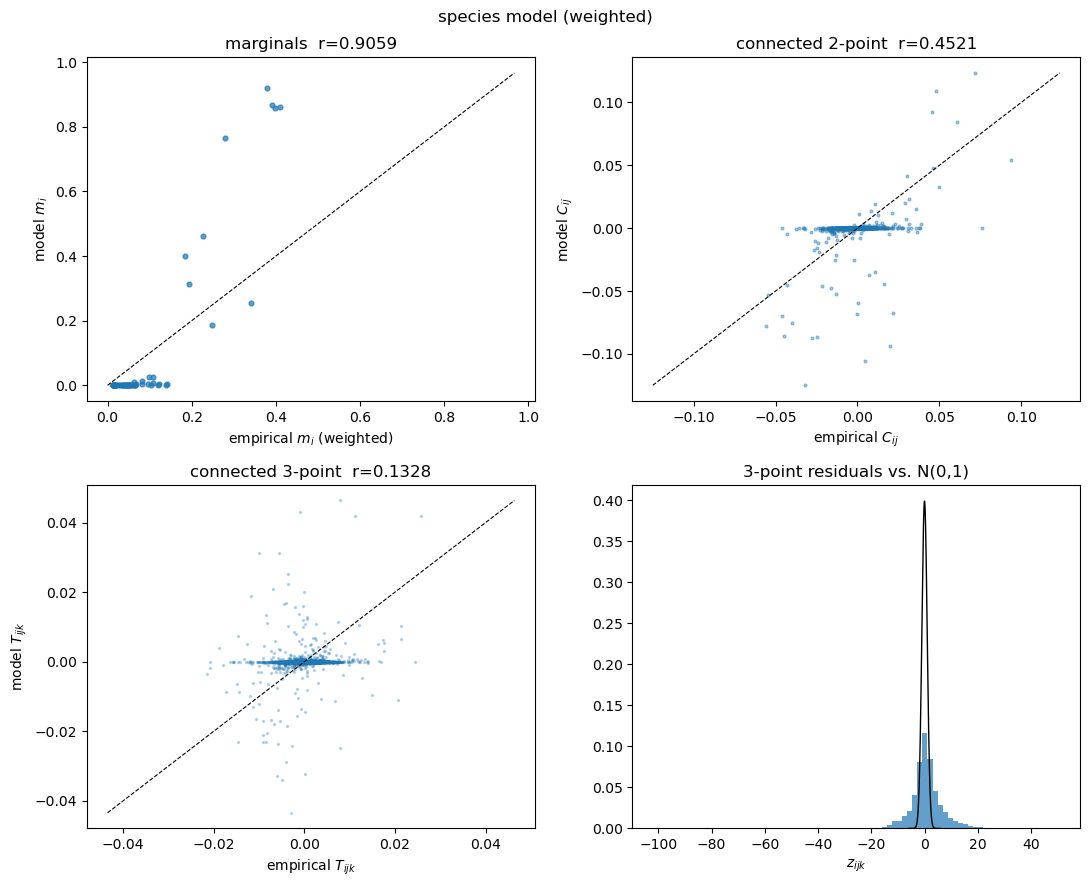

species model (weighted): 34220 triplets over top 60 features
  corr(T_emp, T_model) = 0.1328
  |z|>3: 44.886% (N(0,1) expects 0.270%)   |z|>5: 28.711%


| feature i | feature j | feature k | $T^{emp}$ | $T^{model}$ | $z$ |
| :-- | :-- | :-- | --: | --: | --: |
| Sinistcha | Aerodactyl | Whimsicott | +0.01109 | +0.04178 | -102.1 |
| Eternal Flower Floette | Aerodactyl | Whimsicott | -0.00086 | +0.04294 | -96.5 |
| Incineroar | Aerodactyl | Whimsicott | +0.00785 | +0.04636 | -95.6 |
| Garchomp | Sinistcha | Whimsicott | -0.00369 | +0.02529 | -50.8 |
| Charizard | Pelipper | Delphox | +0.00406 | +0.00001 | +50.8 |
| Charizard | Archaludon | Delphox | +0.00443 | +0.00000 | +48.3 |
| Garchomp | Charizard | Sinistcha | -0.01005 | +0.03132 | -47.9 |
| Incineroar | Sinistcha | Whimsicott | -0.00611 | -0.03296 | +47.7 |
| Charizard | Pelipper | Tyranitar | +0.00579 | +0.00000 | +45.3 |
| Charizard | Pelipper | Froslass | +0.00548 | +0.00002 | +43.9 |
| Charizard | Pelipper | Politoed | +0.00273 | +0.00000 | +43.4 |
| Eternal Flower Floette | Sylveon | Gardevoir | +0.00205 | +0.00001 | +42.1 |
| Aerodactyl | Whimsicott | Talonflame | +0.00437 | +0.00083 | +41.1 |
| Kingambit | Archaludon | Tyranitar | +0.00766 | +0.00000 | +41.1 |
| Charizard | Pelipper | Excadrill | +0.00276 | +0.00000 | +40.6 |

In [15]:
res_sp = compare_three_body(X_sp, w_sp, S_sp, m_sp, vocab_sp,
                            "species model (weighted)")
worst_triplets_table(res_sp)


## Species@item model


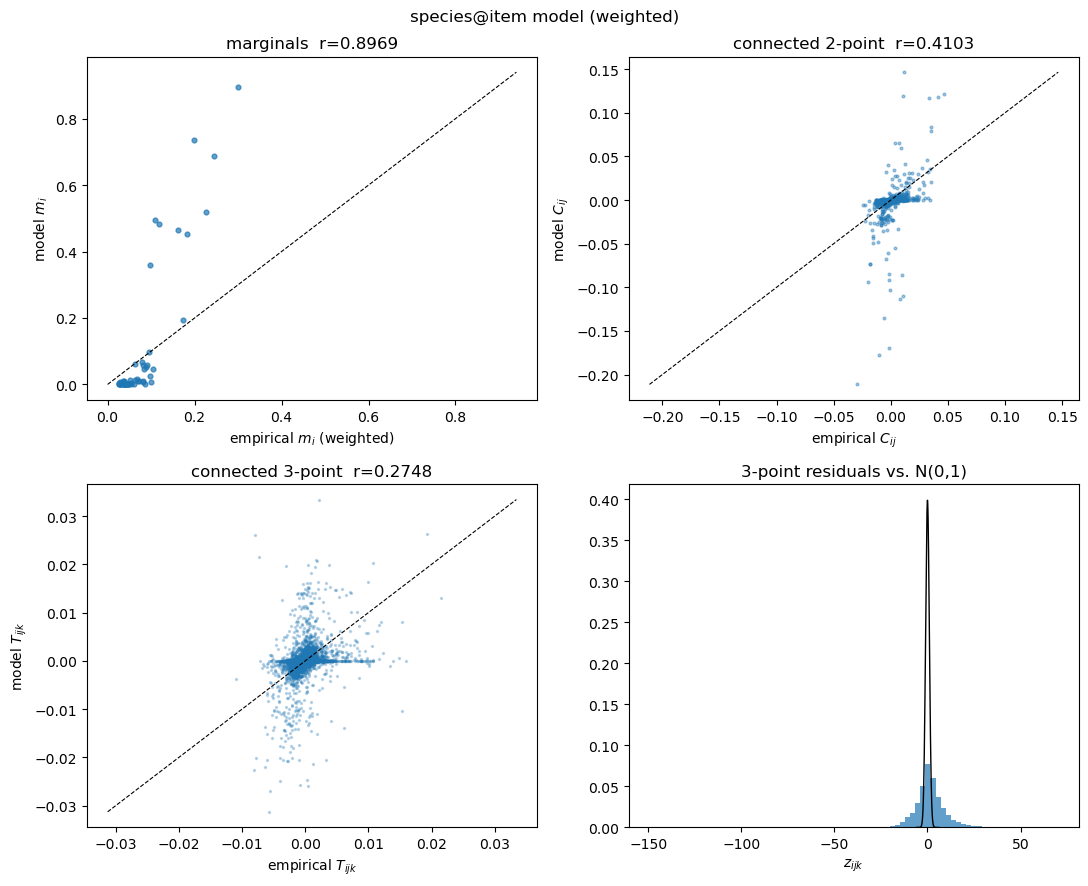

species@item model (weighted): 34220 triplets over top 60 features
  corr(T_emp, T_model) = 0.2748
  |z|>3: 58.887% (N(0,1) expects 0.270%)   |z|>5: 41.555%


| feature i | feature j | feature k | $T^{emp}$ | $T^{model}$ | $z$ |
| :-- | :-- | :-- | --: | --: | --: |
| Whimsicott @ Focus Sash | Aerodactyl @ Focus Sash | Basculegion @ Focus Sash | +0.00173 | +0.02095 | -149.4 |
| Whimsicott @ Focus Sash | Aerodactyl @ Focus Sash | Aerodactyl @ Aerodactylite | +0.00180 | +0.02066 | -143.1 |
| Whimsicott @ Focus Sash | Aerodactyl @ Focus Sash | Sinistcha @ Kasib Berry | +0.00150 | +0.01404 | -92.4 |
| Basculegion @ Choice Scarf | Garchomp @ Sitrus Berry | Garchomp @ Choice Scarf | +0.00210 | +0.03341 | -92.3 |
| Eternal Flower Floette @ Floettite | Whimsicott @ Focus Sash | Aerodactyl @ Aerodactylite | +0.00037 | +0.01995 | -83.9 |
| Garchomp @ Sitrus Berry | Aerodactyl @ Focus Sash | Sinistcha @ Kasib Berry | +0.00113 | +0.01208 | -76.0 |
| Charizard @ Charizardite Y | Incineroar @ Sitrus Berry | Garchomp @ Sitrus Berry | -0.00799 | +0.02605 | -72.4 |
| Eternal Flower Floette @ Floettite | Whimsicott @ Focus Sash | Basculegion @ Focus Sash | -0.00037 | +0.01597 | -71.7 |
| Incineroar @ Sitrus Berry | Garchomp @ Sitrus Berry | Sinistcha @ Sitrus Berry | +0.00354 | +0.00986 | -71.1 |
| Basculegion @ Choice Scarf | Whimsicott @ Focus Sash | Aerodactyl @ Focus Sash | -0.00087 | -0.02576 | +70.3 |
| Garchomp @ Sitrus Berry | Whimsicott @ Focus Sash | Aerodactyl @ Aerodactylite | -0.00249 | -0.01895 | +67.1 |
| Kingambit @ Black Glasses | Whimsicott @ Focus Sash | Basculegion @ Focus Sash | +0.00011 | +0.01387 | -67.1 |
| Whimsicott @ Focus Sash | Sylveon @ Fairy Feather | Aerodactyl @ Focus Sash | +0.00016 | +0.01127 | -64.5 |
| Basculegion @ Choice Scarf | Whimsicott @ Focus Sash | Basculegion @ Focus Sash | +0.00151 | +0.01944 | -62.4 |
| Eternal Flower Floette @ Floettite | Whimsicott @ Focus Sash | Sylveon @ Fairy Feather | +0.00048 | +0.01538 | -62.1 |

In [16]:
res_pr = compare_three_body(X_pr, w_pr, S_pr, m_pr, vocab_pr,
                            "species@item model (weighted)")
worst_triplets_table(res_pr)


## Reading the result

A representative run gives a three-point correlation that barely tracks the data (corr ≈ 0.13 species / 0.15 species@item; $|z|>3$ for roughly 34% / 51% of triplets, against 0.27% under N(0,1)). **This is the expected signature of a pseudo-likelihood fit, not evidence against the pairwise assumption.** PL matches conditionals, not moments, so the generated distribution's 1- and 2-point moments already drift from the data — read the 3-point panel only *relative to* the marginal and 2-point panels above, never as "empirical vs. an ideal pairwise model."

This is **not** a sampling artifact: hotter ladders ($T_{\max}$ 2 → 5 → 10) and doubled steps leave the marginal correlation and the over-concentrated max-marginal unchanged, so the chain is faithfully sampling a genuinely mis-calibrated distribution, and no `field_weight` setting pins the low- and high-order moments at once.

**Consequence for the v2 plan.** A clean Schneidman-style three-body test — and a quantitative read on how good the pairwise PL approximation really is — needs a moment-matched fit: constrained MaxEnt / **Boltzmann learning** (sample-in-loop moment matching, PCD-style accelerator). That is a **separate, deferred track**, off the goodness-model (Stage 4) critical path; nothing downstream depends on the outcome of this notebook. Until that fit exists, the pairwise assumption stands as an unfalsified working assumption supported by downstream *predictive* performance (validation, energy discrimination, outcome ceiling) rather than by this generative diagnostic.

Caveats: in-sample by design; top-$K$ truncation hides rare-feature triplets; model-side SEs slightly optimistic (residual chain autocorrelation).
